#**<font color="Green">LoanTap : Logistic Regression</font>**

**Indroduction**:
LoanTap is a financial technology company that offers personal loans and other financial products in India. It provides customers with easy access to loans through an online platform. LoanTap focuses on offering flexible and customized loan solutions, including personal loans, salary advances, and loans for specific purposes like home renovation, medical expenses, or education.

**Purpose of the Buisness Case study:**
The purpose of this case study is to analyze the Personal Loan segment and gain a deeper understanding of the factors influencing borrower behavior and creditworthiness. By diving into the dataset, we aim to uncover patterns and trends that can provide valuable insights into the financial behaviors, spending habits, and potential risks associated with each borrower.







In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv("/content/logistic_regression.csv")

**<font color='red'>Data Exploration:</font>**

In [ ]:
df.shape

(396030, 27)

The dataset contains 396,030 rows and 27 columns.

In [ ]:
df.sample(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
148039,12000.0,36 months,12.39,400.82,C,C1,manager,3 years,MORTGAGE,45000.0,...,10.0,2.0,4883.0,35.1,19.0,f,INDIVIDUAL,4.0,0.0,"2967 Mcdonald Wall Suite 171\r\nNorth Jeffrey,..."
117228,7000.0,36 months,14.30,240.27,C,C1,Kaiser Permanente,8 years,MORTGAGE,82000.0,...,14.0,0.0,10369.0,47.1,29.0,f,INDIVIDUAL,3.0,0.0,"52463 Vanessa Island\r\nCooperhaven, OR 30723"
331192,11000.0,36 months,6.62,337.75,A,A2,NaN,NaN,MORTGAGE,50000.0,...,5.0,1.0,10017.0,61.5,21.0,w,INDIVIDUAL,3.0,1.0,"71593 Holt Radial\r\nHelenville, CT 00813"
192765,15000.0,36 months,14.96,519.70,D,D2,Abbott Laboratories,2 years,MORTGAGE,96000.0,...,20.0,0.0,20027.0,44.4,29.0,f,INDIVIDUAL,NaN,0.0,"10321 Casey Loaf Apt. 218\r\nSouth Bailey, FL ..."
90469,24000.0,60 months,13.98,558.19,C,C1,Staff Assistant,3 years,RENT,65000.0,...,14.0,0.0,26488.0,75.2,30.0,w,INDIVIDUAL,0.0,0.0,"0042 Calvin Mill\r\nAmandaview, MN 48052"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [ ]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


The columns have data types of float and object. The columns "emp_title," "title," "emp_length," "revol_util," "mort_acc," and "pub_rec_bankruptcies" contain missing values.

**<font color='red'>Non-graphical and graphical analysis</font>**

In [ ]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


**Numeric Columns:**

The column "loan_amnt" has a range of values from 500 to 40,000, with a mean value of 14,113.

The column "int_rate" has a range between 5.32 and 30.99, with a mean value of 13.64.

The "installment" column has a range between 16.08 and 1,533.81, with a mean value of 431.84.

The "annual_inc" column has a range between 0.00 and 8.70, with a mean of 7.42.

The "open_acc" column has a range between 0.00 and 90, with a mean of 11.31.

The "pub_rec_bankruptcies" column has a range between 0.00 and 8.00, with a mean of 0.12.

In [ ]:
df.describe(include="object")

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,address
count,396030,396030,396030,373103,377729,396030,396030,396030,396030,396030,394274,396030,396030,396030,396030
unique,2,7,35,173105,11,6,3,115,2,14,48816,684,2,3,393700
top,36 months,B,B3,Teacher,10+ years,MORTGAGE,Verified,Oct-2014,Fully Paid,debt_consolidation,Debt consolidation,Oct-2000,f,INDIVIDUAL,USS Johnson\r\nFPO AE 48052
freq,302005,116018,26655,4389,126041,198348,139563,14846,318357,234507,152472,3017,238066,395319,8


**Categorical Columns:**

The "term" column has two unique values, with the most frequent value being 36 months.

The "grade" column has 7 unique values, with the most frequent value being B.

The "emp_title" column has 173,105 unique values, with the most frequent value being Teacher.

The "emp_length" column has 11 unique values, with the most frequent value being 11.

The "home_ownership" column has 6 unique values, with the most frequent value being MORTGAGE.

The "loan_status" column has 2 unique values, with the most frequent value being Fully Paid.  

The "application_type" column has 3 unique values, with the most frequent value being INDIVIDUAL.

In [ ]:
import re

**Extracting the city name and zip code from column "address".**

In [ ]:
df["address"] = df["address"].astype("string")

In [ ]:
df["address"].dtype

string[python]

In [ ]:
#Extract Zip Code
pattern=r"[A-Z]{2} \d{5}"
df["zip_code"] = df["address"].apply(lambda x: re.search(pattern, x).group() if re.search(pattern, x) else None)

In [ ]:
# Extract citypart from address
df["city_part"]=df["address"].str.split("\n",n=1, expand=True)[1]

In [ ]:
# Extract city from city_part
df["city"] = df["city_part"].apply(lambda x: x.split(',')[0].strip() if x and ',' in x else None)

In [ ]:
df.drop(["city_part"], axis=1, inplace=True)

In [ ]:
df["city"].isna().sum()

np.int64(42384)

The "city" column has 42,384 null values.

The dataset has a column "issue_month," which contains the loan issue month and year. From this, I am extracting the year and month.

In [ ]:
# Extract Month and Year from issue_d

df["issue_month"]=df["issue_d"].str.split("-").str[0]
df["issue_year"]=df["issue_d"].str.split("-").str[1]

Calculate the number of null values in each row.

In [ ]:
df["null_val"]=df.isnull().sum(axis=1)

In [ ]:
df["null_val"].value_counts(normalize=True)*100

,proportion
null_val,
0,75.756130
1,18.074388
2,5.316264
3,0.815595
4,0.037623


We can see that around 6% of the rows in the dataset have two or more null values, which I will drop.

In [ ]:
df.drop(df[df["null_val"]>1].index, inplace=True)

In [ ]:
df.shape

(371597, 32)

In [ ]:
df.isna().sum()/df.shape[0]*100

,0
loan_amnt,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000
emp_title,0.807326
emp_length,0.030140
home_ownership,0.000000
annual_inc,0.000000


The new data shape is (371597, 32).

In [ ]:
# Convert datatype as float64
df["revol_util"].astype("float64")

,revol_util
0,41.8
1,53.3
2,92.2
3,21.5
4,69.8
...,...
396025,34.3
396026,95.7
396027,66.9
396028,53.8


**Filling missing data:**

In [ ]:
df[df["emp_title"].isna()].describe(include="object")

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,zip_code,city,issue_month,issue_year
count,3000,3000,3000,0,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000
unique,2,7,35,0,11,5,3,54,2,13,1186,442,2,1,479,2708,12,5
top,36 months,B,B4,NaN,10+ years,MORTGAGE,Verified,Dec-2013,Fully Paid,debt_consolidation,Debt consolidation,Oct-2000,f,INDIVIDUAL,MS 22690,Lake William,Dec,2013
freq,2616,962,231,NaN,1351,1613,1545,275,2404,1391,539,28,2256,3000,19,6,383,1723


Looking at the rows with a missing "emp_title," the most common "emp_length" is 10+ years. So, I will fill the "emp_title" with the most frequent title for employees with 10+ years of experience.

**Filling missing values of emp_title:**

In [ ]:
df["emp_title"]=df["emp_title"].fillna(df[df["emp_length"]=="10+ years"]["emp_title"].mode()[0])

In [ ]:
df[df["emp_length"]=="10+ years"].describe(include="object")

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,zip_code,city,issue_month,issue_year
count,124503,124503,124503,124503,124503,124503,124503,124503,124503,124503,123958,124503,124503,124503,124503,112234,124503,124503
unique,2,7,35,63121,1,5,3,108,2,14,15907,632,2,3,540,40552,12,9
top,36 months,B,B3,Teacher,10+ years,MORTGAGE,Verified,Oct-2014,Fully Paid,debt_consolidation,Debt consolidation,Aug-2000,f,INDIVIDUAL,AP 22690,North Michael,Oct,2014
freq,90274,36366,8261,3501,124503,76891,46219,4895,101532,76436,52192,867,71239,124275,642,108,13385,33770


In [ ]:
df["emp_length"]=df["emp_length"].fillna(df["emp_length"].mode()[0])

**Filling missing values of title:**

In [ ]:
df[df["title"].isna()].describe(include="object")

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,zip_code,city,issue_month,issue_year
count,1359,1359,1359,1359,1359,1359,1359,1359,1359,1359,0,1359,1359,1359,1359,1359,1359,1359
unique,2,7,34,1035,11,3,3,12,2,12,0,346,2,3,428,1289,11,4
top,36 months,C,C4,Owner,10+ years,MORTGAGE,Source Verified,Mar-2016,Fully Paid,debt_consolidation,NaN,Aug-2000,w,INDIVIDUAL,ME 70466,New Kimberly,Mar,2016
freq,933,410,90,26,545,717,609,292,1111,816,NaN,15,1068,1294,11,4,292,1333


In [ ]:
df["title"]=df["title"].fillna(df[df["emp_title"]=="Owner"]["title"].mode()[0])

**Filling missing values of revol_util:**

In [ ]:
df["revol_util"].fillna(df["revol_util"].median(), inplace=True)

/tmp/ipython-input-113-473879321.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["revol_util"].fillna(df["revol_util"].median(), inplace=True)


**Filling missing values of mort_acc:**

In [ ]:
df["mort_acc"].fillna(df["mort_acc"].median(), inplace=True)

/tmp/ipython-input-114-335100157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["mort_acc"].fillna(df["mort_acc"].median(), inplace=True)


**Filling missing values of city:**

In [ ]:
df[df["city"].isna()].describe(include="object")

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,zip_code,city,issue_month,issue_year
count,35850,35850,35850,35850,35850,35850,35850,35850,35850,35850,35850,35850,35850,35850,35850,0,35850,35850
unique,2,7,35,22010,11,5,3,58,2,13,4907,571,2,3,30,0,12,5
top,36 months,B,B4,Manager,10+ years,MORTGAGE,Source Verified,Oct-2014,Fully Paid,debt_consolidation,Debt consolidation,Aug-2000,f,INDIVIDUAL,AP 70466,NaN,Oct,2014
freq,27299,10434,2356,466,12269,18159,12312,1554,28710,21882,15370,289,19913,35794,1831,NaN,3946,10394


In [ ]:
df["city"] = df["city"].fillna(df[df["emp_length"]=="10+ years"]["city"].mode()[0])

Similarly to "emp_title," I filled the NaN values with the mean for numerical columns and the mode value for categorical columns.

In [ ]:
# Drop columns issue_d, address and null_val
df.drop(["issue_d","address","null_val"], axis=1, inplace=True)

In [ ]:
df.shape

(371597, 29)

In [ ]:
# list of numeric columns
df_num=df.columns[df.dtypes=="float64"]
df_num

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

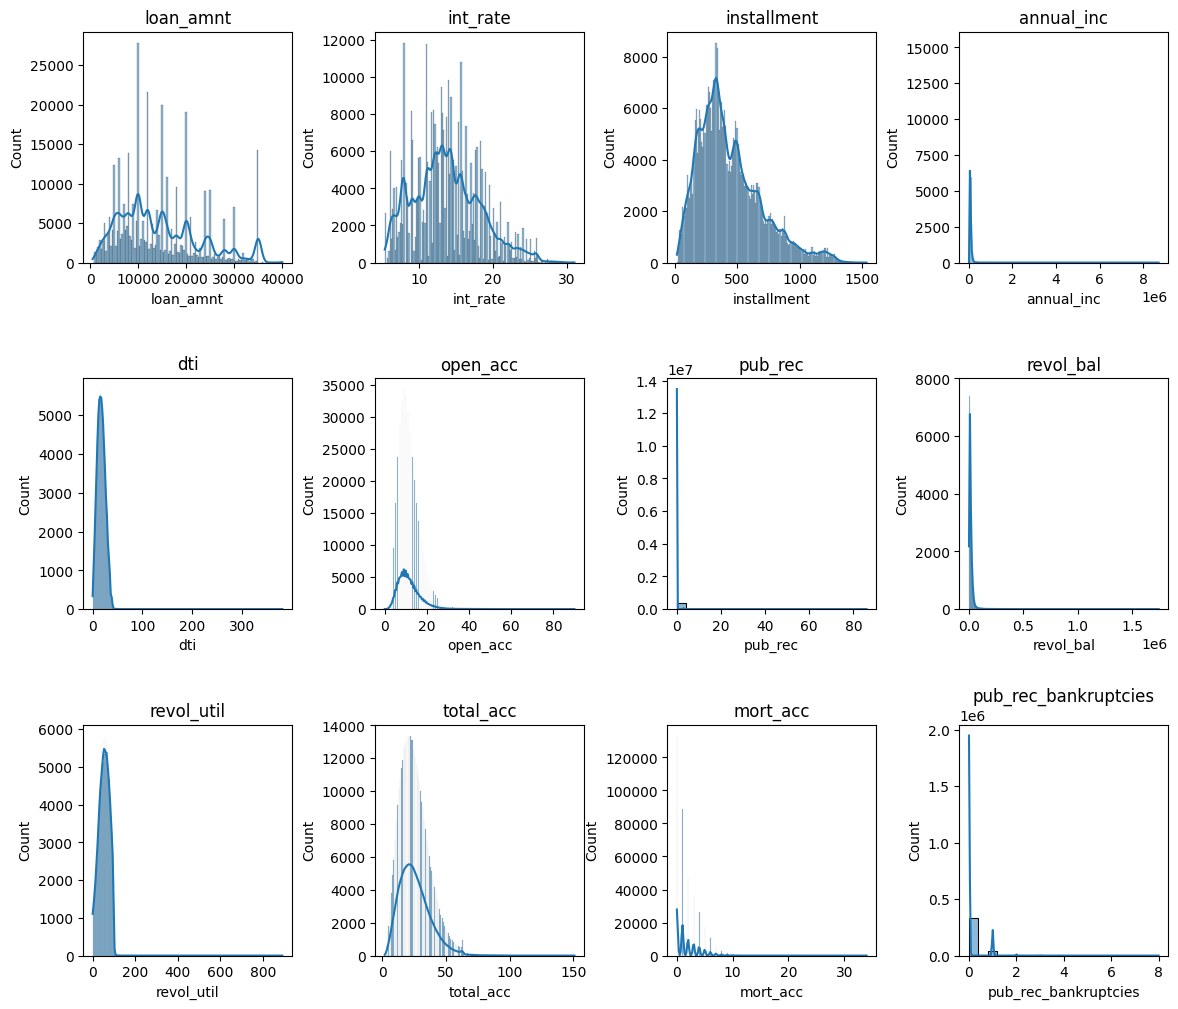

In [ ]:
#Graph for Numeric Columns

plt.figure(figsize=(14,12))
for i,col in enumerate(df_num):
  plt.subplot(3,4,i+1)
  sns.histplot(df[col], kde=True)
  plt.title(col)
plt.subplots_adjust(wspace=0.4,hspace=0.5)
plt.show()


Here, we can observe that the plots of numeric datatype columns are right-skewed, which indicates that the dataset has some very large positive outliers.

**Categorical Datatype:**

Text(0.5, 1.0, "Top 20 Loan's Titles")

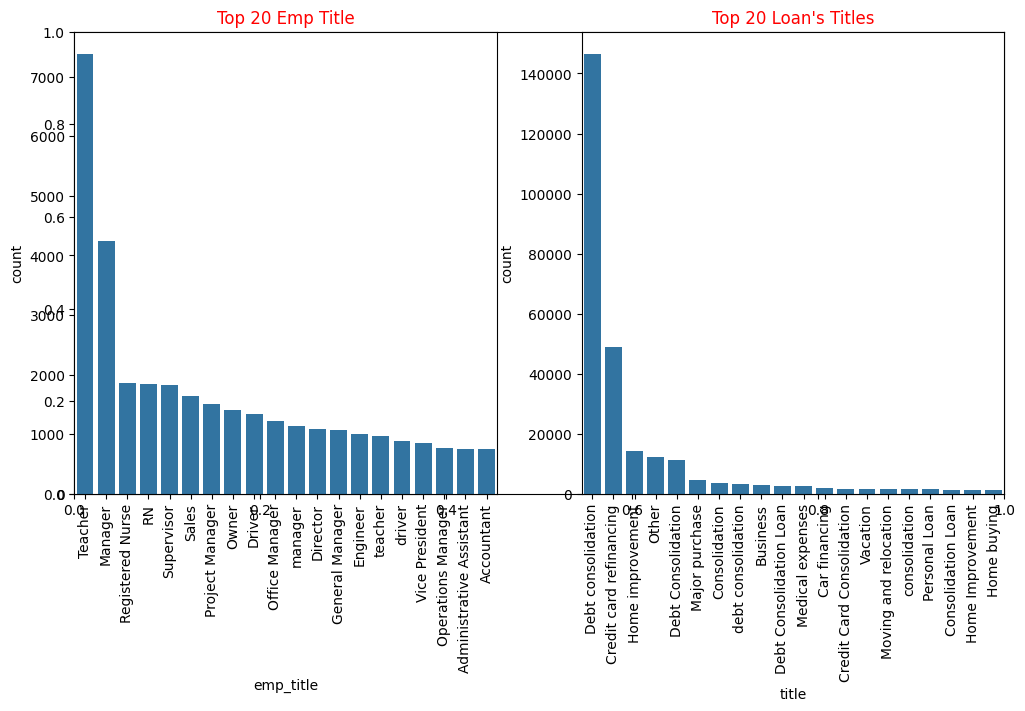

In [ ]:
# Top 20 "emp_title":Borrower's job title
plt.subplots(figsize=(12,6))
plt.subplot(1,2,1)
sns.barplot(df["emp_title"].value_counts().sort_values(ascending=False)[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Emp Title", color="red")

# Top 20 Loan's title: The loan's title provided by the borrower.
plt.subplot(1,2,2)
sns.barplot(df["title"].value_counts().sort_values(ascending=False)[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Loan's Titles", color="red")

We can observe that Teacher is the top occupation of borrowers, followed by Manager and Registered Nurse.
The top 10 loan titles provided by borrowers are:
Debt Consolidation is the most common title, followed by Credit Card Refinancing and Home Improvement.

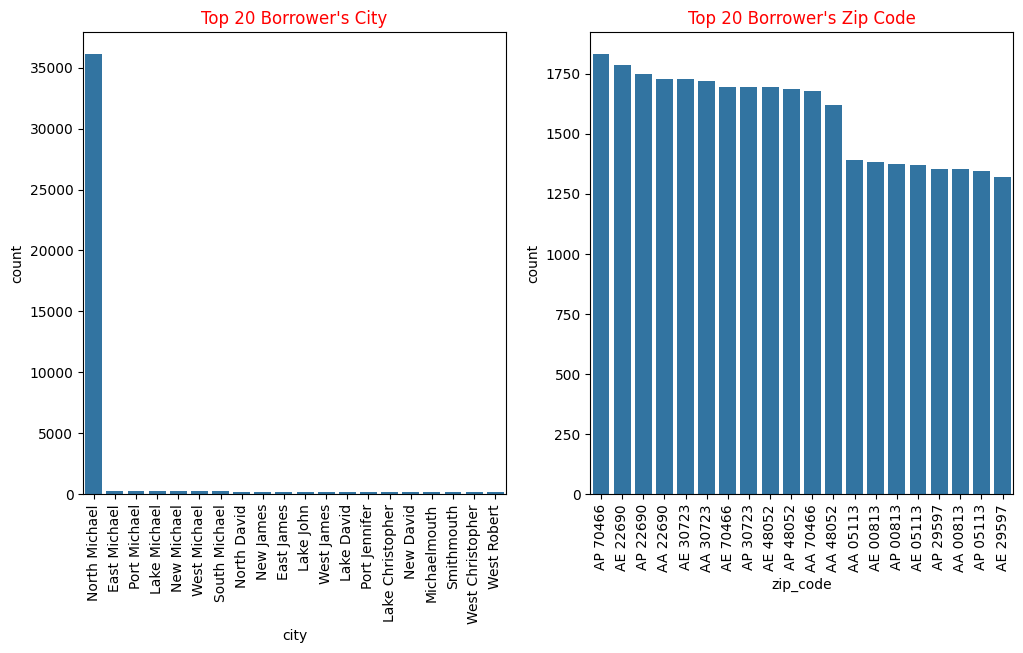

In [ ]:
# Top 20 Borrower's City and Zip_Code
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.barplot(df["city"].value_counts().sort_values(ascending=False)[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Borrower's City", color="red")


plt.subplot(1,2,2)
sns.barplot(df["zip_code"].value_counts().sort_values(ascending=False)[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Borrower's Zip Code", color="red")
plt.show()

"North Michael" is the top city of borrowers, followed by "East Michael" and "Port Michael."

In [ ]:
# Ctegorical columns
df_cat=df.columns[df.dtypes=="object"]


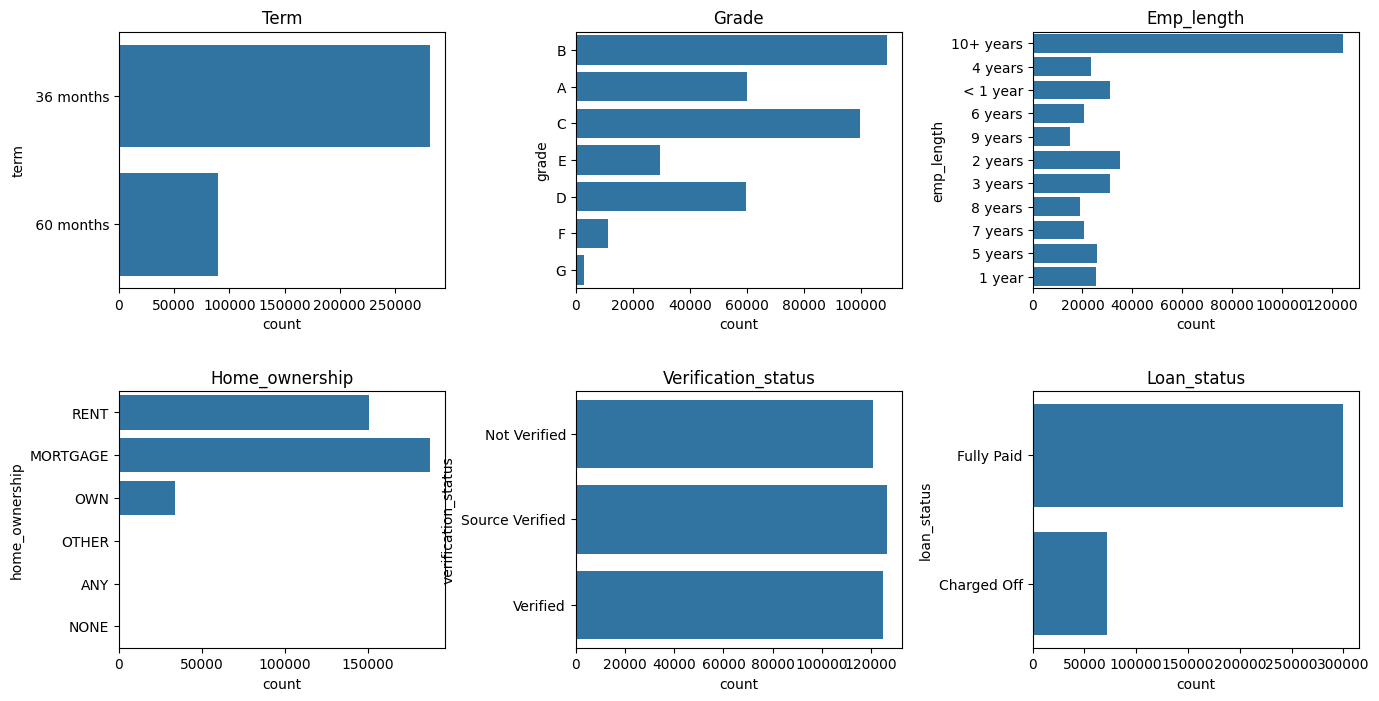

In [ ]:
# Plots of term, grade, emp_length, home_ownership, loan_status, purpose
plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
sns.countplot(df["term"])
plt.title("Term")

plt.subplot(2,3,2)
sns.countplot(df["grade"])
plt.title("Grade")

plt.subplot(2,3,3)
sns.countplot(df["emp_length"])
plt.title("Emp_length")

plt.subplot(2,3,4)
sns.countplot(df["home_ownership"])
plt.title("Home_ownership")

plt.subplot(2,3,5)
sns.countplot(df["verification_status"])
plt.title("Verification_status")

plt.subplot(2,3,6)
sns.countplot(df["loan_status"])
plt.title("Loan_status")

plt.subplots_adjust(wspace=0.4,hspace=0.4)
plt.show()




**<font color="red">Observations:</font>**

**Term:** We can observe that 36 months is the most opted loan duration, accounting for 75.76% of the total loans.

**Grade:** Risk ratings by LoanTap show that most customers fall under Grade B (29.30%), indicating low-risk borrowers, followed by Grade C (26.83%) and Grade A (16.12%) of the total loans.

**Emp_length:** Most borrowers have an employment length of more than 10 years, representing 33.55% of the total loans.

**Home Ownership:** The majority of borrowers have a mortgage (50.38%), followed by those renting (40.53%). Only a small percentage (around 9%) own their homes.

**Verification Status:** Most borrowers are source verified and verified (33.96% and 33.58%, respectively), but a large number of borrowers' sources are not verified (32.45% of all loans).

**Loan Status:** The majority of borrowers' loan status is "Fully Paid" (81%), while the remaining 19% are "Charged Off."

**Purpose:** Borrowers' reasons for loans show that debt consolidation is the most popular reason, accounting for around 60%, followed by credit card refinancing (20%) and home improvement (6%).

**Applicant Type:** 99% of applicants are individuals.
**Issue Year:** Most loans were issued in 2014 (26%), followed by 2013 (25%) and 2015 (24%).

**Issue Month:** The most common months for loan issuance are October (10.65%), followed by July (10.12%) and January (8.69%).

**Bivariate Analysis:**


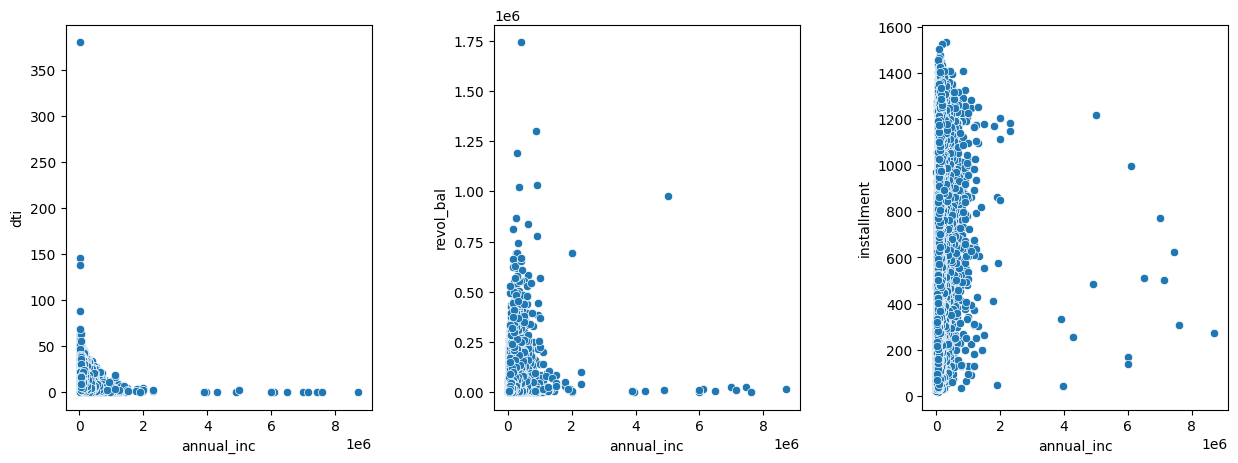

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.scatterplot(x=df["annual_inc"], y=df["dti"])

plt.subplot(1,3,2)
sns.scatterplot(x=df["annual_inc"], y=df["revol_bal"])

plt.subplot(1,3,3)
sns.scatterplot(x=df["annual_inc"], y=df["installment"])

plt.subplots_adjust(wspace=0.4,hspace=0.5)
plt.show()


**<font color="red">Observations:</font>**

**Annual_inc vs DTI**: We can observe that most borrowers have a low DTI, with some exceptions of low-income borrowers having very high DTI.

**Annual_inc vs Revol_bal (Total credit balance):** Most borrowers with low income have a low total credit balance, but there are also several outliers with low income and high credit balances.

**Annual_inc vs Installment:** We can observe that the installment amount is spread in the range of 0 to 1600 for lower-income borrowers.

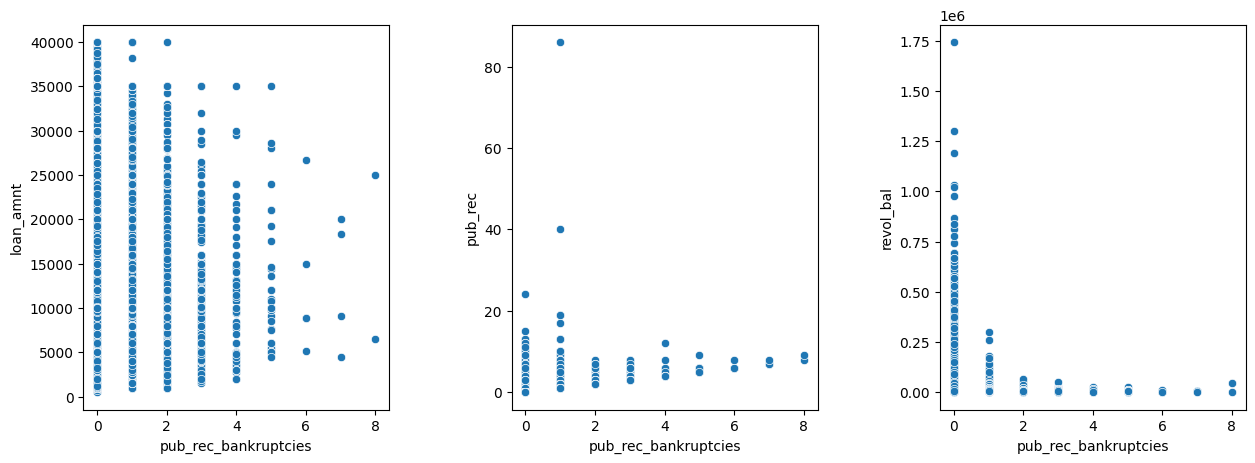

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.scatterplot(x=df["pub_rec_bankruptcies"], y=df["loan_amnt"])

plt.subplot(1,3,2)
sns.scatterplot(x=df["pub_rec_bankruptcies"],  y=df["pub_rec"])

plt.subplot(1,3,3)
sns.scatterplot(x=df["pub_rec_bankruptcies"], y=df["revol_bal"])

plt.subplots_adjust(wspace=0.4,hspace=0.5)
plt.show()


**<font color="red">Observations:</font>**

**loan_amnt vs pub_rec_bankruptcies:** Borrowers with higher loan amounts have zero bankruptcy records, but for borrowers with lower loan amounts, bankruptcy records range from zero to very high.

**pub_rec vs pub_rec_bankruptcies:** The lower the number of negative records on a borrower's public credit profile, the lower the number of bankruptcy records.

**revol_bal vs pub_rec_bankruptcies:** The higher the credit balance, the lower the number of bankruptcy records.

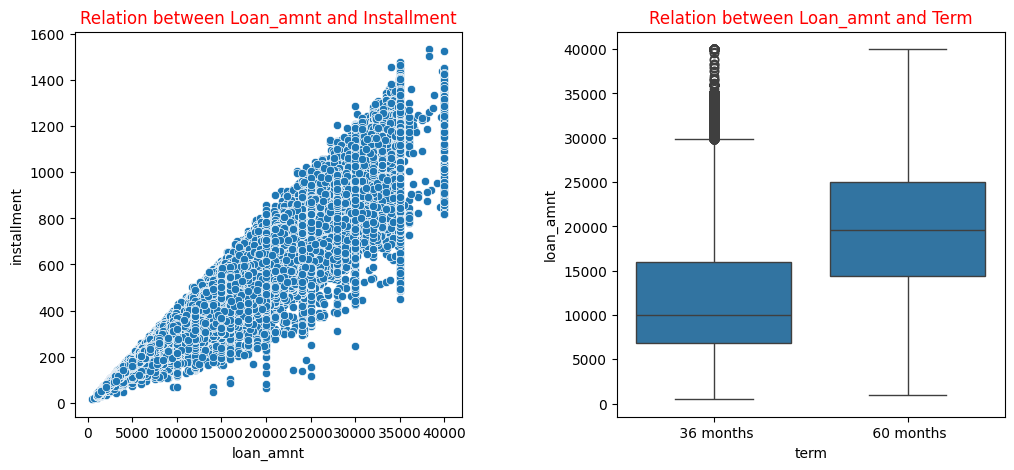

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=df["loan_amnt"], y=df["installment"])
plt.title("Relation between Loan_amnt and Installment", color="red")

plt.subplot(1,2,2)
sns.boxplot(x=df["term"], y=df["loan_amnt"])
plt.title("Relation between Loan_amnt and Term", color="red")

plt.subplots_adjust(wspace=0.4,hspace=0.5)
plt.show()


**<font color="red">Observations:</font>**

**Loan_amnt vs Installment:** We can observe that loan amount and installment have a positive linear relationship. Installment increases as the loan amount increases, with a few exceptions.

**Loan_amnt vs Term:** Borrowers who opt for a 36-month term have a mean loan amount of 10,000, with a large number of outliers. Some borrowers with loan amounts greater than 30,000 also opt for the 36-month term. Borrowers who opt for a 60-month term have a mean loan amount of 20,000.

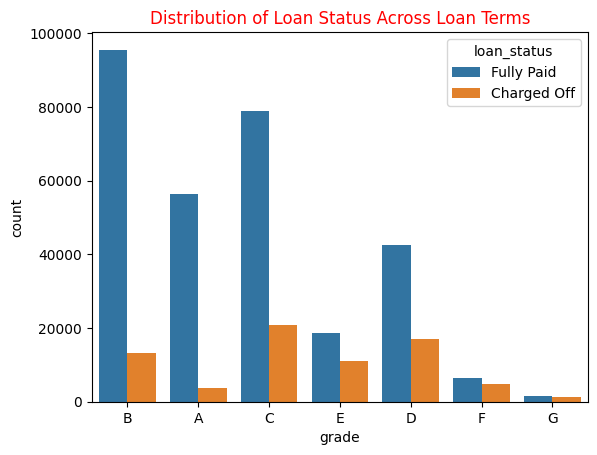

In [ ]:
# categorical_ categorical

sns.countplot(x=df["grade"], hue=df["loan_status"])
plt.title("Distribution of Loan Status Across Loan Terms", color="red")
plt.show()

Borrowers with grade B have the most "Fully Paid" loans, followed by grade A and grade C borrowers.

In [ ]:
# Top 10 emp_title by Highest Avg Incmoe
job_vs_income=df.groupby("emp_title")["annual_inc"].mean().sort_values(ascending=False)
job_vs_income[:10]

,annual_inc
emp_title,
Correctional Sgt.,8706582.0
Interim Director of Case Management,7600000.0
Legal admin asst,7000000.0
BOONE AND SONS JEWELERS,6100000.0
VISIUM asset management,5000000.0
Child Nutrition Assistant I,4300000.0
3rd cook,3964280.0
Lea Regional Hospital/Pecos Valley,3900000.0
"President, Alternative and Late night",2000000.0


Borrowers with the "emp_title" Correctional Sgt have the highest average annual income of 8,706,582.0, followed by Interim Director of Case Management with an annual income of 7,600,000.0, and Legal Admin Asst. with an annual income of 7,000,000.0.

In [ ]:
# Top 10 emp_title of borrowers who have fully paid their loans.
df[df["loan_status"]=="Fully Paid"]["emp_title"].value_counts()[:10]

,count
emp_title,
Teacher,5932
Manager,3319
Registered Nurse,1474
RN,1467
Supervisor,1425
Project Manager,1257
Sales,1238
Office Manager,970
Driver,960


Teacher is the top "emp_titl"e with the most number of fully paid loans, totaling 5,932, followed by Manager with 3,319 fully paid loans, and Registered Nurse with 1,474 fully paid loans.

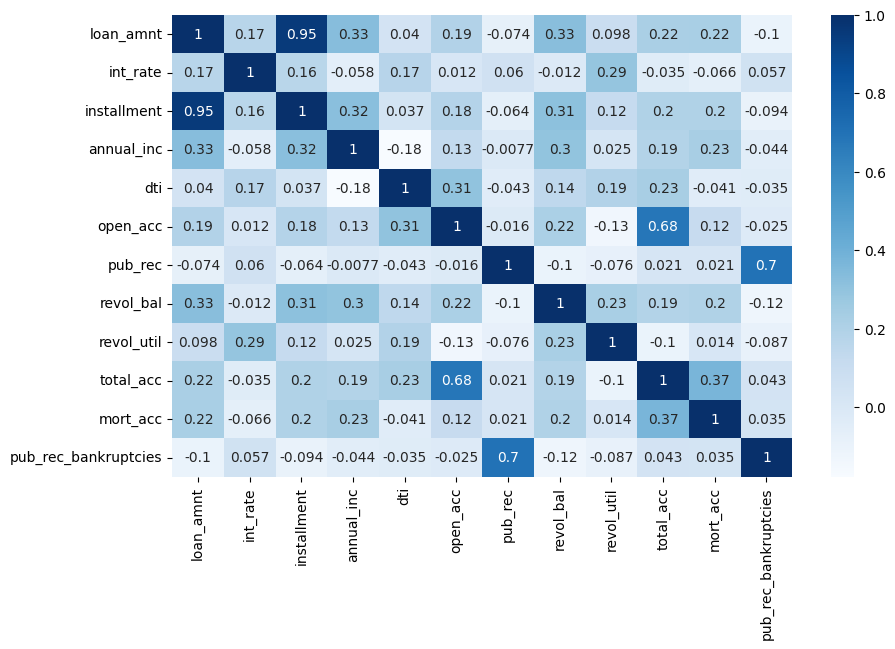

In [ ]:
# Correlation Plot
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="Blues")
plt.show()

**<font color="red">Observations:</font>**

We can observe that loan_amnt and installment have a very strong positive correlation of 0.95, which is close to 1. As the loan amount increases, the installment (monthly payment) also increases almost proportionally.

A correlation of 0.33 between loan_amnt (loan amount) and annual_income indicates a weak positive correlation. As annual income increases, the loan amount also tends to increase, but this relationship is not very strong.

loan_amnt and revol_bal (total credit balance) also have a positive correlation.

A correlation of -0.1 between pub_rec_bankruptcies (bankruptcy records for borrowers) and loan_amnt (the amount borrowed) indicates a very weak negative correlation. This suggests that as the number of bankruptcy records increases, the loan amount tends to decrease slightly.

A correlation coefficient of -0.1 between pub_rec (negative records on the borrower's public credit profile) and revol_bal (total credit balance) indicates a weak negative correlation. This suggests that as the number of negative records (pub_rec) increases, the total credit balance (revol_bal) tends to decrease.

The correlation of 0.33 between annual_inc (borrower's yearly income) and loan_amnt indicates a weak positive correlation. This suggests that as annual income increases, the loan amount also tends to increase, but the relationship is not very strong.

A correlation of -0.18 between annual_inc and dti (Debt-to-Income ratio) indicates a weak negative correlation. This suggests that as annual income increases, the debt-to-income ratio tends to decrease slightly, with higher-income individuals typically having lower debt-to-income ratios.

A correlation of 0.35 between mort_acc (number of borrower's mortgages) and pub_rec_bankruptcies (bankruptcy records for borrowers) indicates a moderate positive correlation. As the number of mortgages increases, the number of bankruptcy records also tends to increase.

A correlation of 0.7 between pub_rec and pub_rec_bankruptcies indicates a strong positive correlation, suggesting that as the number of negative records on a borrower's public credit profile increases, the number of bankruptcy records also tends to increase.

**<font color ="red">Outlier Treatment:</font>**

In [ ]:
# Counting number of Outliers present in each column

L=[]
for col in df_num:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  upper_limit=Q3+1.5*IQR
  lower_limit=Q1-1.5*IQR
  outliers=df[(df[col]>upper_limit) | (df[col]<lower_limit)]
  L.append(outliers.shape[0])


for i ,j in zip(df_num,L):
  print(f"{i} : {j} ")


loan_amnt : 184 
int_rate : 2986 
installment : 10297 
annual_inc : 16557 
dti : 238 
open_acc : 9951 
pub_rec : 52937 
revol_bal : 19837 
revol_util : 11 
total_acc : 8084 
mort_acc : 6471 
pub_rec_bankruptcies : 41141 


As we can see, some of the columns have a large number of outliers, which is causing the data to be right-skewed. Removing them could lead to data loss, so I am applying a log transformation to convert the right-skewed data distribution to a more normal distribution.

In [ ]:
# Log Transformation

df[df_num]=df[df_num].apply(lambda x: np.log1p(x))

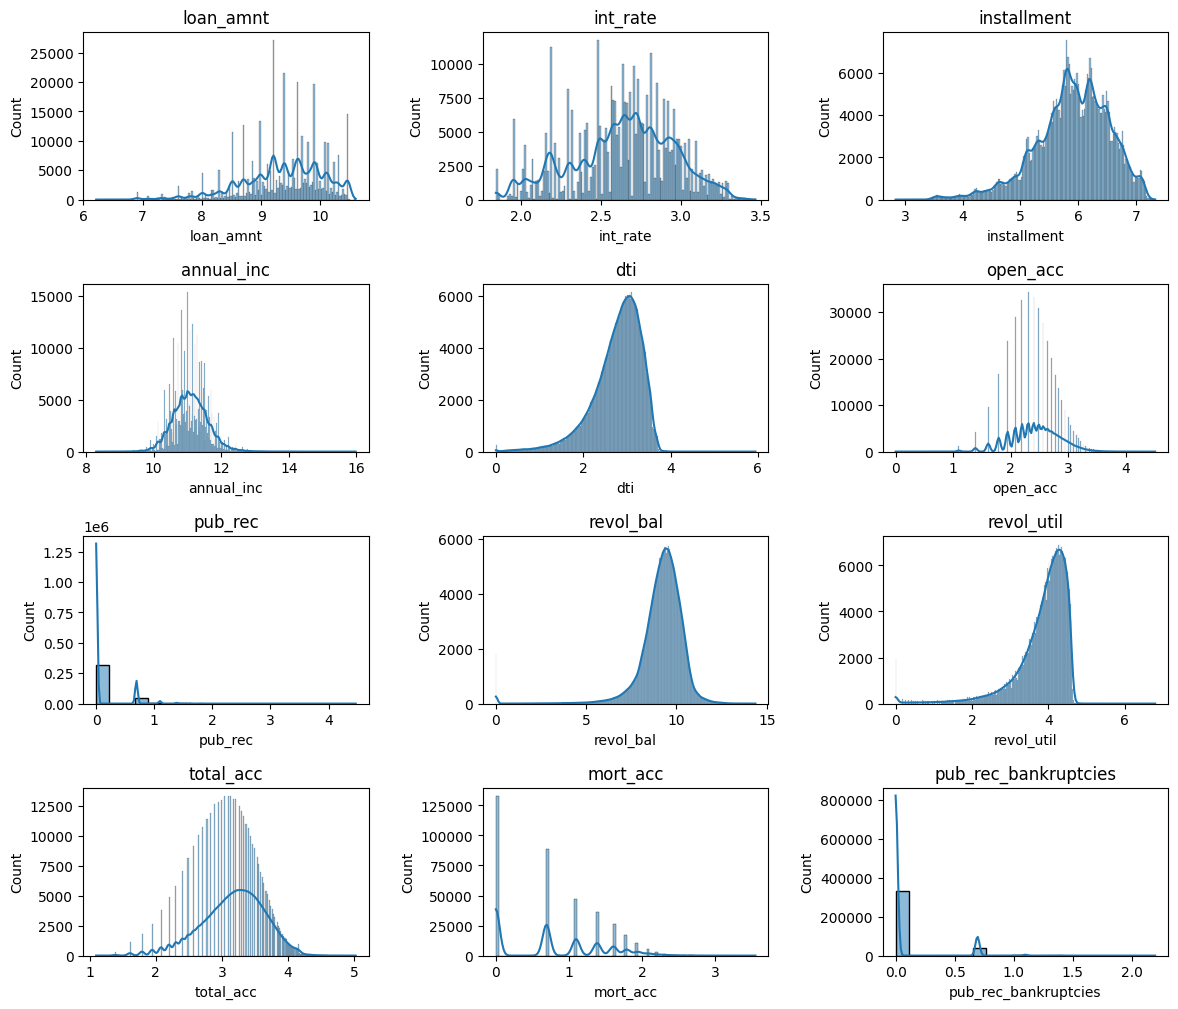

In [ ]:
plt.figure(figsize=(14,12))
for i,col in enumerate(df_num):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.subplots_adjust(wspace=0.4,hspace=0.5)
plt.show()


**<font color="red">Feature Engineering:</font>**

In [ ]:
# Performing Label Encoding on Categorical columns which have 2 to 3 unique values
from sklearn.preprocessing import LabelEncoder

df["term"]=LabelEncoder().fit_transform(df["term"])
df["verification_status"]=LabelEncoder().fit_transform(df["verification_status"])
df["loan_status"]=LabelEncoder().fit_transform(df["loan_status"])
df["purpose"]=LabelEncoder().fit_transform(df["purpose"])
df["initial_list_status"]=LabelEncoder().fit_transform(df["initial_list_status"])
df["application_type"]=LabelEncoder().fit_transform(df["application_type"])

In [ ]:
# Creating list of columns of remaing categorical column
df_cat_temp=df_cat.drop(["term", "verification_status", "loan_status", "purpose", "initial_list_status", "application_type"])

In [ ]:
# Performing Target Encoding on columns which have large number of unique values
for col in df_cat_temp:
  df[col]=df.groupby(col)["pub_rec_bankruptcies"].transform("mean")

In [ ]:
# Range of feature

In [ ]:
# Creating Flag column
df["mort_acc_flag"]= df["mort_acc"].apply(lambda x: 1 if x>0 else 0)

df["pub_rec_flag"]=df["pub_rec"].apply(lambda x: 1 if x>0.5 else 0)

df["bankruptcies_flag"]=df["pub_rec_bankruptcies"].apply(lambda x: 1 if x>0.5 else 0)


In [ ]:
# Droping original column after creating Flag Columns
df.drop(["pub_rec_bankruptcies", "mort_acc", "pub_rec"], axis=1, inplace=True)

In [ ]:
# Linearity between

**<font color="red">Data Preparation for Model Training:</font>**

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Spliting the data into Independent and Dependent Variable
y=df["bankruptcies_flag"]
x=df.drop("bankruptcies_flag", axis=1)

In [ ]:
# Spliting the data into Training and Test Datasets
x_tr_cv, x_test, y_tr_cv,  y_test= train_test_split(x,y, test_size=0.2, random_state=2)

# Spliting the data into Training and Validation Datasets
x_train, x_val, y_train, y_val= train_test_split(x_tr_cv, y_tr_cv, test_size=0.25, random_state=2)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train),columns=x_train.columns)
x_test=  pd.DataFrame(scaler.transform(x_test), columns=x_train.columns)
x_val=  pd.DataFrame(scaler.transform(x_val), columns=x_train.columns)

In [ ]:
# Data shape after data split
x_train.shape, x_test.shape, x_val.shape

((222957, 28), (74320, 28), (74320, 28))

In [ ]:
# VIF to check Multicollinearity of Features
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Initialize the VIF DataFrame
vif = pd.DataFrame()
vif["Features"] = x_train.columns

# Calculate VIF for each feature
vif["VIF"] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]

# Round VIF values to 2 decimal places
vif["VIF"] = round(vif["VIF"], 2)

# Sort VIF values in descending order
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

               Features     VIF
0             loan_amnt  521.34
3           installment  466.00
1                  term   31.00
2              int_rate   14.40
5             sub_grade   10.52
4                 grade    8.82
17            revol_bal    2.71
19            total_acc    2.50
16             open_acc    2.47
18           revol_util    2.46
9            annual_inc    1.75
27         pub_rec_flag    1.72
6             emp_title    1.59
14                  dti    1.51
26        mort_acc_flag    1.44
25           issue_year    1.42
15     earliest_cr_line    1.29
20  initial_list_status    1.23
8        home_ownership    1.21
13                title    1.19
10  verification_status    1.17
12              purpose    1.16
23                 city    1.16
11          loan_status    1.10
7            emp_length    1.09
24          issue_month    1.02
22             zip_code    1.00
21     application_type    1.00


A VIF value greater than 5 indicates multicollinearity. The feature 'Loan_amnt' has a VIF value of 521, which indicates extreme multicollinearity; therefore, this feature needs to be dropped.

In [ ]:
 x_train.drop("loan_amnt", axis=1, inplace=True)

In [ ]:
# Check VIF
vif=pd.DataFrame()
vif["Features"]=x_train.columns
vif["VIF"]=[variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif["VIF"]=round(vif["VIF"],2)
vif.sort_values(by="VIF", ascending=False)

,Features,VIF
4,sub_grade,9.47
3,grade,8.82
1,int_rate,3.89
16,revol_bal,2.71
18,total_acc,2.50
15,open_acc,2.47
17,revol_util,2.46
8,annual_inc,1.75
26,pub_rec_flag,1.72
5,emp_title,1.59


The VIF value of 'sub_grade' is 9.47, indicating that the feature is multicollinear. Therefore, also dropped this feature.

In [ ]:
# Drop column sub_grade
x_train.drop("sub_grade", axis=1, inplace=True)

In [ ]:
# Again check vif
vif=pd.DataFrame()
vif["Features"]=x_train.columns
vif["VIF"]=[variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif=round(vif,2)
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
1,int_rate,3.59
3,grade,2.80
15,revol_bal,2.71
17,total_acc,2.50
14,open_acc,2.47
16,revol_util,2.45
7,annual_inc,1.75
25,pub_rec_flag,1.72
4,emp_title,1.59
2,installment,1.56


**<font color="red">Data Modeling:</font>**

In [ ]:
# Model Training : logistic Regression

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
model.coef_

array([[ 6.03816782e-02,  1.91844846e-02, -7.22567587e-02,
        -8.02798721e-02,  2.60725002e+00, -3.27322085e-02,
         2.31012955e-01, -2.74654722e-01, -8.06747424e-02,
         8.90905837e-02, -1.02009160e-01,  6.32659490e-01,
        -3.93608910e-02,  2.16665940e-01, -1.87921228e-01,
        -2.18109336e-01,  9.35890779e-02,  4.75621920e-01,
        -2.10452599e-02,  1.16703173e-02,  1.35077380e-01,
         1.49061051e+00, -2.60508010e-03, -2.31408958e-01,
         2.44043515e-01,  5.07973250e+00]])

In [ ]:
#model.coef.sort_value()

In [ ]:
model.intercept_

array([-12.58212243])

In [ ]:
# Accuracy Score of Training data
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
print("Accuracy score for training data :", accuracy_score(y_train, model.predict(x_train)))


Accuracy score for training data : 0.9853020986109429


In [ ]:
# Drop feature "loan_amnt" and "sub_grade" from validation test data set
x_val.drop(["loan_amnt", "sub_grade"], axis=1, inplace=True)
x_test.drop(["loan_amnt", "sub_grade"], axis=1, inplace=True)

In [ ]:
# Accuracy Score of Validation dataset
print("Accuracy score for test data :", accuracy_score(y_val, model.predict(x_val)))

Accuracy score for test data : 0.984997308934338


The accuracy score of the training dataset is 0.98530, and the accuracy score of the validation dataset is 0.98499, which are extremely close. This indicates that the model is performing well on both datasets.

**Data Distribution:**

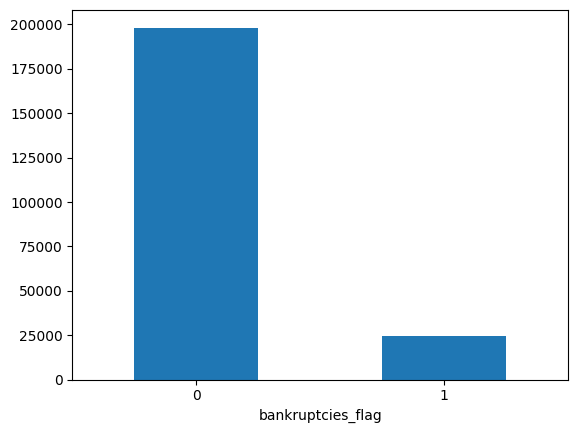

In [ ]:
# The data distribution of Target Feature
y_train.value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.show()

We can see that the data distribution is imbalanced. The high accuracy score indicates that the model is biased toward the majority class.

**<font color="red">Data Imbalance Treatment</font>**

In [ ]:
# SMOTE for Data Imbalance Treatment
from imblearn.over_sampling import SMOTE
smt=SMOTE()

print("Before SMOTE")
print(y_train.value_counts())

x_sm, y_sm=smt.fit_resample(x_train, y_train)

print("After SMOTE")
print(y_sm.value_counts())

Before SMOTE
bankruptcies_flag
0    198248
1     24709
Name: count, dtype: int64
After SMOTE
bankruptcies_flag
0    198248
1    198248
Name: count, dtype: int64


In [ ]:
# Traing new balance data on model
model=LogisticRegression()
model.fit(x_sm, y_sm)

LogisticRegression()

In [ ]:
model.coef_

array([[ 7.03650146e-02, -6.84654308e-05, -3.14928091e-02,
        -3.27595590e-02,  4.13764857e+00, -3.49634741e-03,
         2.33260371e-01, -2.56739274e-01, -9.74788884e-02,
         1.50377826e-01, -1.31157489e-01,  6.93823191e-01,
        -4.50779837e-02,  3.01147302e-01, -1.59788644e-01,
        -3.25527570e-01,  2.06327750e-01,  5.15872858e-01,
        -1.11181280e-02,  5.20477070e-03,  1.66025644e-01,
         2.21677100e+00, -8.66679105e-03, -2.21074336e-01,
         2.28294631e-01,  7.53938263e+00]])

In [ ]:
model.intercept_

array([-16.90088761])

In [ ]:
model.score(x_sm, y_sm)

0.9894954804083774

After balancing the data, I checked the accuracy score again, which is 0.9856, similar to the training data score before applying SMOTE.

**Confusion Matrix:**

In [ ]:
# Confusion matrix to evaluate the model's performance.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred= model.predict(x_sm)
conf_matrix= confusion_matrix(y_sm, y_pred)
conf_matrix

array([[194311,   3937],
       [   228, 198020]])

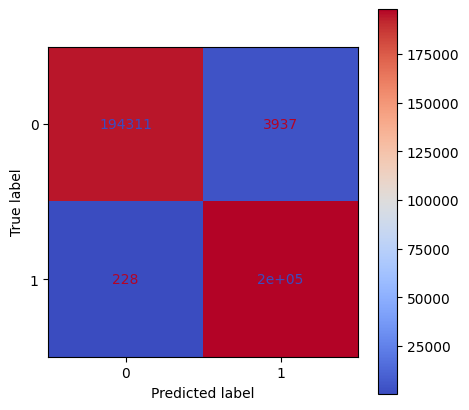

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(conf_matrix).plot(ax=ax, cmap="coolwarm")
plt.show()

In [ ]:
# Precision_score, Recall Score and F1 Score
precision_score=conf_matrix[1,1]/(conf_matrix[1,1]+conf_matrix[0,1])
recall_score=conf_matrix[1,1]/(conf_matrix[1,1]+conf_matrix[1,0])
f1_score=2*precision_score*recall_score/(precision_score+recall_score)
print("Precision Score :", precision_score)
print("Recall Score :", recall_score)
print("F1 Score :", f1_score)

Precision Score : 0.9805057512242705
Recall Score : 0.9988499253460312
F1 Score : 0.9895928336727428


The confusion matrix shows that the model is performing well at correctly identifying both True Positives and True Negatives, with very few False Positives and False Negatives. A precision score of about 0.98 indicates that the model is great at avoiding false positives. A recall score of about 0.999 means the model is excellent at identifying almost all positive cases. The F1 score of around 0.99 demonstrates that the model maintains a good balance between precision and recall.

In [ ]:
# Score of Validation Dataset

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy Score of Validation Dataset :", model.score(x_val, y_val))
print("Precision Score of Validation Dataset :", precision_score(y_val, model.predict(x_val)))
print("Recall Score of Validation Dataset :", recall_score(y_val, model.predict(x_val)))
print("F1 Score of Validation Dataset :", f1_score(y_val, model.predict(x_val)))

Accuracy Score of Validation Dataset : 0.9823600645855759
Precision Score of Validation Dataset : 0.8626279863481229
Recall Score of Validation Dataset : 0.997164344717051
F1 Score of Validation Dataset : 0.9250300223022817


**Model score on Validation Dataset:**

Precision Score of the Validation Dataset: 0.8623, which indicates that the model is correct about 86% of the time while predicting the classes.

Recall Score of the Validation Dataset: 0.9969, indicating that the model is able to identify the actual positive class very effectively.

F1 Score of the Validation Dataset: 0.9247, showing a good balance between precision and recall.

The precision and recall scores of the validation data are lower than those of the training data, indicating that the model is making a few mistakes on the unseen dataset.

**Hyperparameter Tuning:**

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [i for i in range(1,100,10)],
    'penalty': ['l1', 'l2']
}

grid_search=GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid_search.fit(x_sm, y_sm)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

Best Parameters: {'C': 51, 'penalty': 'l2'}
Best Score: 0.9894727827175792


In [ ]:
grid_search.best_estimator_

LogisticRegression(C=51, max_iter=1000)

In [ ]:
#  Accuracy Score of Model After Hyperparameter Tunning
best_model=grid_search.best_estimator_
best_model.score(x_val, y_val)

0.9823869752421959

The score slightly dropped from 0.9893 to 0.9823 after hyperparameter tuning.

Again plotting the confusion matrix to check the performance.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred= best_model.predict(x_val)
conf_matrix_val= confusion_matrix(y_val, y_pred)
conf_matrix_val

array([[64924,  1285],
       [   24,  8087]])

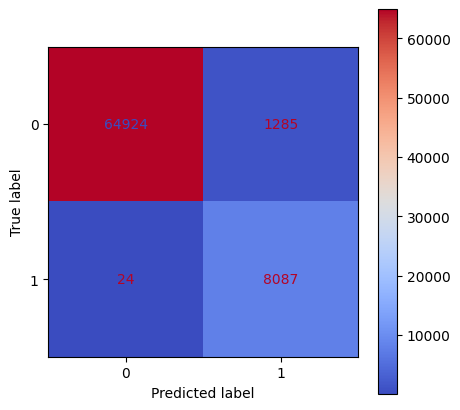

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(conf_matrix_val).plot(ax=ax, cmap="coolwarm")
plt.show()

In [ ]:
# Precision score, Recall score and F1 score of Validation dataset

print("Precision Score:" , conf_matrix_val[1,1]/(conf_matrix_val[1,1] + conf_matrix_val[0,1]))
print("Recall Score:" , conf_matrix_val[1,1]/(conf_matrix_val[1,1] + conf_matrix_val[1,0]))
print("F1 Score:" , 2*conf_matrix_val[1,1]/(2*conf_matrix_val[1,1] + conf_matrix_val[0,1] + conf_matrix_val[1,0]))

Precision Score: 0.8628894579598805
Recall Score: 0.9970410553569227
F1 Score: 0.9251272664874449


**<font color="red">Observations:</font>**

**Percision Score, Recall Score and F1 Score before Hyperparameter tuning:**

Precision Score: 0.8623
Recall Score: 0.9969
F1 Score : 0.9247

**Precision Score, Recall Score, and F1 Score after Hyperparameter Tuning:**

Precision Score: 0.8627
Recall Score: 0.9970
F1 Score: 0.9250

The scores of the model is approx same with slight improvement after hyperparameter tuning, which indicates that the model is optimized.



**Coefficients of Features**

In [ ]:
cof_list=zip(x_sm.columns, best_model.coef_[0])
cof_list=sorted(cof_list, key=lambda x: x[1], reverse=True)
cof_list


[('pub_rec_flag', np.float64(8.139892775405986)),
 ('emp_title', np.float64(4.1703618070618615)),
 ('city', np.float64(2.2344248321785893)),
 ('title', np.float64(0.6890741985643901)),
 ('total_acc', np.float64(0.5157876830122472)),
 ('earliest_cr_line', np.float64(0.301581362133143)),
 ('home_ownership', np.float64(0.2292895130915722)),
 ('mort_acc_flag', np.float64(0.22658647444316007)),
 ('revol_util', np.float64(0.20553220847195475)),
 ('zip_code', np.float64(0.16643320690771635)),
 ('loan_status', np.float64(0.1507447235837064)),
 ('term', np.float64(0.07145860213941976)),
 ('application_type', np.float64(0.0053888810918018126)),
 ('int_rate', np.float64(-0.0002225947976810937)),
 ('emp_length', np.float64(-0.003997075008081772)),
 ('issue_month', np.float64(-0.008761940653102701)),
 ('initial_list_status', np.float64(-0.012311537710107647)),
 ('grade', np.float64(-0.0324568699976357)),
 ('installment', np.float64(-0.03306150652003951)),
 ('dti', np.float64(-0.04417379768480218)),

**<font color="red">Observation & Insights:</font>**

The feature 'pub_rec_flag' has a positive relationship with the target variable, meaning the presence of 'pub_rec_flag' increases the likelihood of the positive class.
Followed by 'emp_title' (4.17), 'city' (2.24), and 'title' (0.68), which also have a positive relationship with the target class.


**ROC-AUC Curve and Precision-Recall Curve:**


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
probability = best_model.predict_proba(x_val)
probability

array([[9.15103582e-01, 8.48964178e-02],
       [1.00000000e+00, 8.49704334e-11],
       [1.00000000e+00, 2.01175283e-11],
       ...,
       [9.99999996e-01, 4.03760997e-09],
       [3.65990647e-02, 9.63400935e-01],
       [9.99999999e-01, 5.56240981e-10]])

In [ ]:
probabilites = probability[:,1]

In [ ]:
fpr, tpr, thr = roc_curve(y_val,probabilites)

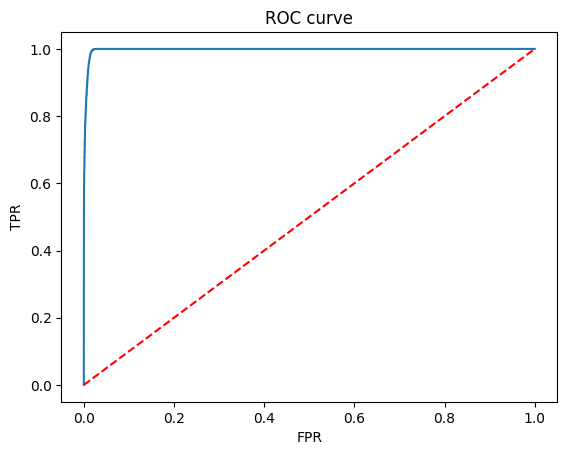

In [ ]:
plt.plot(fpr,tpr)

#random model
plt.plot(fpr,fpr,'--',color='red' )
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [ ]:
# AUC
roc_auc_score(y_val,probabilites)

np.float64(0.9978845323013031)

Precision Recall curve

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
precision, recall, thresholds = precision_recall_curve(y_val, probabilites)

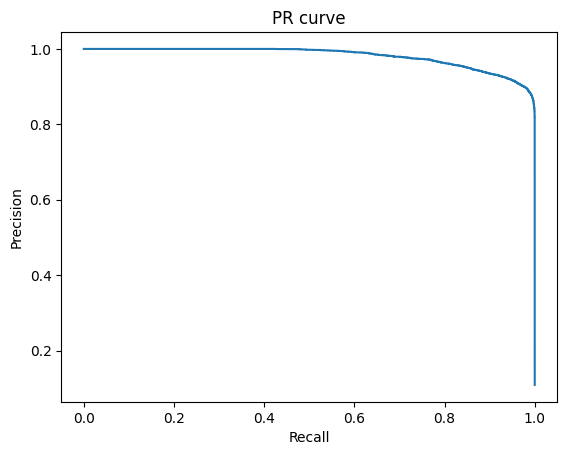

In [ ]:
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR curve')
plt.show()

In [ ]:
auc(recall, precision)

np.float64(0.9813976712363648)

**<font color="red">Observations:</font>**

The ROC AUC score of 0.9978 is extremely high, indicating that the model is capable of perfectly distinguishing between positive and negative classes.

The Precision-Recall AUC is 0.98. From the graph, we observe that the model is able to maintain high precision with high recall.
This indicates that the model is capable of distinguishing between the classes while keeping False Positives and False Negatives very low, making it a good model for fraud detection and risk profiling.

Accuracy Score, Prescision Score , Recall Score and F1 score of Test data

In [ ]:
print("Accuracy Score for Test Data:", best_model.score(x_test, y_test))
print("Precision Score for Test Data:", precision_score(y_test, best_model.predict(x_test)))
print("Recall Score for Test Data:", recall_score(y_test, best_model.predict(x_test)))
print("F1 Score for Test Data:", f1_score(y_test, best_model.predict(x_test)))

Accuracy Score for Test Data: 0.9816603875134553
Precision Score for Test Data: 0.8617928452579035
Recall Score for Test Data: 0.9959139526499219
F1 Score for Test Data: 0.9240118191447845


# **<font color="red">Insights:</font>**

**<font color="red">Model Performance:</font>**

The model performs similarly well on both validation and test datasets, suggesting that it generalizes well to unseen data.

The high recall score of 0.9956 indicates that the model is extremely effective at identifying instances of the positive class, meaning it is very sensitive and rarely misses true positives.

The precision score of 0.8617 is somewhat lower than the recall, suggesting that while the model is excellent at detecting positive cases, it might occasionally misclassify negative cases as positive.

The F1 score of 0.9238 reflects a good balance between precision and recall, indicating that the model is both accurate in its predictions (high precision) and effective in capturing most of the positive cases (high recall).

Precision measures the proportion of true positives among predicted positives. A lower precision indicates the model is misclassifying negative cases as positive. Recall measures the proportion of true positives among actual positives. A lower recall means the model misses actual positive cases. In a bank's risk classification, recall is more important, as false negatives (high-risk customers classified as low-risk) can lead to significant financial losses. While recall is critical, poor precision (false positives) can damage the bank's reputation and result in losses by wrongly classifying low-risk customers as high-risk.

Gap between Precision and Recall:
The Presision- Recall AUc of model is 0.98 at 0.99 recall it Precision is arround 0.90 which shows than model have small gap, while model predicting most positive classes it is also predecting false positive classes.

While the model performs well, there might be room for improvement in precision without compromising recall.

**<font color="red">Customer Profiling:</font>**

Top Occupations: Teacher is the most common occupation, followed by Manager and Registered Nurse.

Term: 36 months is the most commonly chosen loan duration, accounting for 75.76% of the total loans.

Grade: Most borrowers are in Grade B (29.30%), indicating low risk, followed by Grade C (26.83%) and Grade A (16.12%).

Borrowers with grade B have the most Fully Paid loans, followed by grade A and grade C borrowers.

Emp_length: Most borrowers have more than 10 years of employment, representing 33.55% of the total loans.

Home Ownership: Most borrowers have a mortgage (50.38%), followed by renters (40.53%), with around 9% owning their homes.

Loan Status: Most loans are Fully Paid (81%), with the remaining 19% charged off.
Purpose: Debt consolidation is the most common reason for loans (around 60%), followed by credit card refinancing (20%) and home improvement (6%).

**Correlation Insights:**

Loan Amount vs. Installment: A strong positive correlation (0.95), suggesting that as the loan amount increases, the installment amount increases almost proportionally.

Mortgages vs. Bankruptcy Records: A moderate positive correlation (0.35), indicating that as the number of mortgages increases, bankruptcy records also tend to increase.

Public Records vs. Bankruptcy Records: A strong positive correlation (0.7), suggesting that as the number of negative records increases, so does the number of bankruptcy records.

Affected by geographical location:
A positive coefficient of 2.2372 means that as the 'city' feature increases, the likelihood of the positive class also increases. This shows that the 'city' feature has a strong positive impact on the outcome.


**<font color="red">Risk Profile:</font>**

**Low Risk:**

* Occupations such as Teacher, Manager, and Registered Nurse with Grade A and Grade B ratings.
* Borrowers with long employment histories (more than 10 years) and homeowners with a mortgage.
* Loan purposes related to Home Improvement.
* Fully paid loan statuses.
* Borrowers with low loan amounts and reasonable installment amounts.

**Moderate Risk:**

* Borrowers with Grade C ratings, higher loan amounts, or those applying for debt consolidation or credit card refinancing.
* Renters or those with shorter employment histories.
* Borrowers with a moderate number of mortgages and public records.

**High Risk:**

* Borrowers with multiple bankruptcies, high debt-to-income ratios, and a high number of public records.
* Loans with higher loan amounts and longer terms.
* Borrowers with a history of charged off loans.

# **<font color="red">Recommendations:</font>**

1. The model has very high recall (0.9959) but lower precision (0.8617), meaning it sometimes labels low-risk customers as high-risk; adding more features could help improve precision.

2. Segment customers by risk: offer premium products and lower rates to low-risk occupations like teachers, managers, and nurses with Grade A or B ratings.

3. For medium-risk borrowers (Grade C, renters, or shorter employment), send regular reminders and explain the benefits of resolving debt.

4. Apply stricter approval rules for high-risk customers (those with multiple bankruptcies or high debt-to-income ratios) and require secured loans or extra documents.

5. Create special products with risk-based pricing and extra monitoring for common loan reasons like debt consolidation and credit card refinancing.

6. Use public records and bankruptcy history in risk scoring, and make approval harder for those with many negative records.

7. Analyze geographic data to find high-risk areas and adjust lending policies or marketing efforts as needed.

8. Regularly track model metrics (precision, recall, F1, AUC) to spot problems early and retrain the model with new data to keep it accurate and fair.
